# Amazon 2025 Electronics Market Analysis

### Environment Setup
We start by importing the necessary libraries for data manipulation, visualization, and machine learning.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
pd.set_option('display.max_columns', None)

Load the cleaned dataset into a pandas DataFrame.


In [4]:
# Load the dataset from PostgreSQL (Production Module)
from src.db import get_engine
from src.models import AmazonSales
import pandas as pd

engine = get_engine()
# Read latest snapshot
query = "SELECT * FROM amazon_sales WHERE snapshot_date = (SELECT MAX(snapshot_date) FROM amazon_sales)"
df = pd.read_sql(query, engine)
print(f"Loaded {len(df)} rows from the latest snapshot.")

Loaded 42675 rows from the latest snapshot.


Data shows 1,024 missing values for both product_rating and total_reviews. This suggests these might be new products that haven't received feedback yet.

### Handling Missing Values

We address missing values in `product_rating` and `total_reviews` using an intelligent imputation strategy that distinguishes between genuine missing data and 'New Arrivals'.

In [5]:
# Apply Production Cleaning Logic
from src.cleaning import clean_sales_data

# The SQL data might arguably be raw or partially cleaned. 
# We run the standard cleaning pipeline to ensure consistency.
df = clean_sales_data(df)
print("Applied src.cleaning.clean_sales_data")
display(df.head())

Applied src.cleaning.clean_sales_data


,id,snapshot_date,product_title,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,discount_percentage,is_best_seller,is_sponsored,has_coupon,buy_box_availability,delivery_date,sustainability_tags,product_image_url,product_page_url,data_collected_at,product_category,discount_percentage_fixed,badge_category,is_best_seller_flag,is_amazons_choice,is_new_arrival,has_buy_box
0,1,2026-02-03,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375.0,300.0,89.68,159.00,43.60,No Badge,Sponsored,Save 15% with coupon,Add to cart,2025-09-01,Carbon impact,https://m.media-amazon.com/images/I/71pAqiVEs3...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Phones,43.60,No Badge,False,False,False,True
1,2,2026-02-03,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457.0,6000.0,9.99,15.99,37.52,No Badge,Sponsored,No Coupon,Add to cart,2025-08-29,NaN,https://m.media-amazon.com/images/I/61nbF6aVIP...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Laptops,37.52,No Badge,False,False,False,True
2,3,2026-02-03,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,3044.0,2000.0,314.00,349.00,10.03,No Badge,Sponsored,No Coupon,Add to cart,2025-09-01,NaN,https://m.media-amazon.com/images/I/61h78MEXoj...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Laptops,10.03,No Badge,False,False,False,True
3,4,2026-02-03,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",4.6,35882.0,10000.0,162.24,162.24,0.00,Best Seller,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61SUj2aKoE...,https://www.amazon.com/Apple-Cancellation-Tran...,2025-08-21 11:14:29,Phones,0.00,Best Seller,True,False,False,False
4,5,2026-02-03,Apple AirTag 4 Pack. Keep Track of and find Yo...,4.8,28988.0,10000.0,72.74,72.74,0.00,No Badge,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61bMNCeAUA...,https://www.amazon.com/Apple-MX542LL-A-AirTag-...,2025-08-21 11:14:29,Phones,0.00,No Badge,False,False,False,False


In [6]:
# Statistical summary of numerical columns
display(df.describe().T)

# Check the balance of your categorical targets
print(df['is_best_seller'].value_counts(normalize=True))

,count,mean,min,25%,50%,75%,max,std
id,42675.0,21338.0,1.0,10669.5,21338.0,32006.5,42675.0,12319.355706
product_rating,41651.0,4.399431,1.0,4.2,4.5,4.7,5.0,0.386997
total_reviews,41651.0,3087.106,1.0,82.0,343.0,1886.0,865598.0,13030.460133
purchased_last_month,32164.0,1293.665278,50.0,100.0,200.0,400.0,100000.0,6318.323574
discounted_price,40613.0,243.227289,2.16,29.69,84.99,224.0,5449.0,473.351545
original_price,40613.0,257.611107,2.16,32.99,89.0,229.99,5449.0,496.633495
discount_percentage,40613.0,6.547151,0.0,0.0,0.0,8.49,85.42,12.744715
data_collected_at,42675,2025-08-26 12:06:45.470462,2025-08-21 11:14:29,2025-08-24 21:57:14,2025-08-25 11:27:13,2025-08-29 11:22:04,2025-08-30 19:56:33,NaN
discount_percentage_fixed,40613.0,6.547151,0.0,0.0,0.0,8.49,85.42,12.744715


is_best_seller
No Badge             0.956391
Amazon's             0.017434
Limited time deal    0.009584
Best Seller          0.006444
Save 30%             0.002929
Ends in              0.002273
Save 10%             0.001429
Save 18%             0.001336
Save 17%             0.001195
Save 12%             0.000609
Save 9%              0.000328
Save 77%             0.000047
Name: proportion, dtype: float64


- The max for reviews is 865,598, while the mean is only 3,013. Similarly, purchased_last_month has a max of 100,000 against a median 50% of just 200. This is a clear indication of a right-skewed distribution, with a few products commanding most of the sales volume.
- The min for product rating is 0.0. Need to verify whether these are truly "1-star" products or just products with zero reviews. Usually, Amazon ratings start at 1. If a product has 0.0 rating and 0 reviews, it’s a "New Arrival."
- The 50% percentile for discount_percentage is 0.0 - this tells us that more than half of dataset consists of products sold at their full original price.

### Exploratory Data Analysis (EDA)
Visualizing the distribution of key variables like `purchased_last_month` to understand the data's shape and detect skewness.

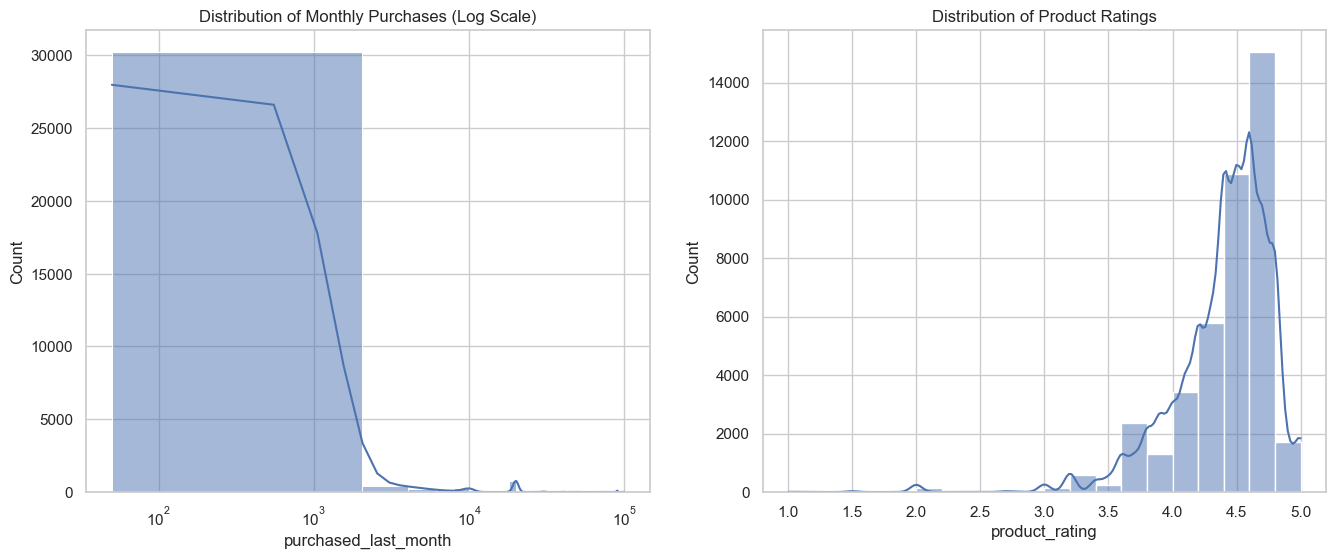

In [7]:
# Visualising the skewness of sales
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(df['purchased_last_month'], bins=50, kde=True, ax=ax[0])
ax[0].set_xscale('log')
ax[0].set_xscale('log')
ax[0].set_xscale('log')
ax[0].set_title('Distribution of Monthly Purchases (Log Scale)')

sns.histplot(df['product_rating'], bins=20, kde=True, ax=ax[1])
ax[1].set_title('Distribution of Product Ratings')

plt.show()

In [8]:
# Create specific boolean flags for better analysis
df['is_best_seller_flag'] = df['is_best_seller'].str.contains('Best Seller', case=False, na=False)
df['is_amazons_choice'] = df['is_best_seller'].str.contains("Amazon's", case=False, na=False)

# Capture limited time offers (urgency markers)
urgency_keywords = ['Limited time deal', 'Ends in', 'Save']
df['has_promo_tag'] = df['is_best_seller'].str.contains('|'.join(urgency_keywords), case=False, na=False)

# Group everything else as "Standard"
def simplify_badge(val):
    if 'Best Seller' in str(val): return 'Best Seller'
    if "Amazon's" in str(val): return "Amazon's Choice"
    if any(k in str(val) for k in urgency_keywords): return 'Promotional'
    return 'No Badge'

df['badge_category'] = df['is_best_seller'].apply(simplify_badge)

# Verify the cleaning
print(df['badge_category'].value_counts())

badge_category
No Badge           40814
Promotional          842
Amazon's Choice      744
Best Seller          275
Name: count, dtype: int64


In [9]:
import re

# Identify rows where discount_percentage is null or 0, but the badge mentions a 'Save' amount
# This regex extracts the digits from strings like 'Save 77%'
def extract_discount_from_badge(row):
    if pd.isna(row['discount_percentage']) or row['discount_percentage'] == 0:
        match = re.search(r'Save (\d+)%', str(row['is_best_seller']))
        if match:
            return float(match.group(1))
    return row['discount_percentage']

# Apply the patch
df['discount_percentage_fixed'] = df.apply(extract_discount_from_badge, axis=1)

# Report the 'Data Recovery'
recovered_count = (df['discount_percentage_fixed'] != df['discount_percentage']).sum()
print(f"Successfully recovered discount data for {recovered_count} products.")

Successfully recovered discount data for 2062 products.


In [10]:
# Create a 'Product Age' or 'Maturity' signal
df['is_new_arrival'] = (df['product_rating'] == 0) & (df['total_reviews'] == 0)

# Verify the logic
print("New Arrival vs Rated Product Purchase Volume:")
print(df.groupby('is_new_arrival')['purchased_last_month'].mean())

New Arrival vs Rated Product Purchase Volume:
is_new_arrival
False    1293.665278
Name: purchased_last_month, dtype: float64


### Correlation Analysis
Examining the correlation between numerical features to identify potential relationships.


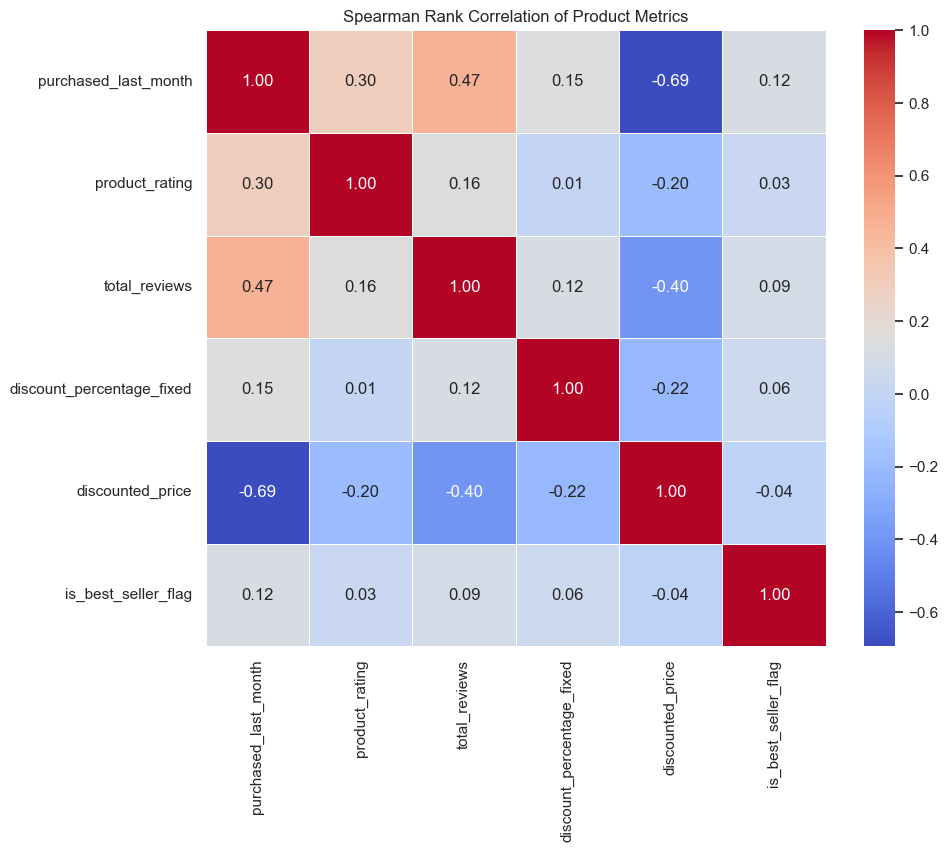

In [11]:
import numpy as np

# Select numerical columns for correlation
# We use Spearman because our data (sales/reviews) is not normally distributed
cols_to_corr = [
    'purchased_last_month', 'product_rating', 'total_reviews', 
    'discount_percentage_fixed', 'discounted_price', 'is_best_seller_flag'
]

corr_matrix = df[cols_to_corr].corr(method='spearman')

# Plotting
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Spearman Rank Correlation of Product Metrics')
plt.show()

- Most striking figure from the heatmap is the -0.69 correlation between "discounted price" and "purchased last month". This is very strong inverse relationship which demonstrates that as the price goes up, the volume of salese drops significantly. **While this seems like basic economics, in the electronics category, it suggests that high-volume sales are dominated by low-cost accessories (cables, chargers, screen protectors) rather than premium hardware (laptops, high-end cameras).**

- The correlation between total_reviews and purchased_last_month is 0.47, thus review count is a better predictor of sales than the actual product_rating (0.30). **This shows that Amazon customers are more influenced by the quantity of social proof than a slightly higher rating. A 4.3-star product with 10,000 reviews is likely outperforming a 4.8-star product with 50 reviews.**

- Data shows clear "discount trap" - correlation between discount_percentage_fixed and purchased_last_month is only 0.15. **It suggests that a high discount percentage on its own doesn't actually drive massive sales volume as much as the final price point does.**



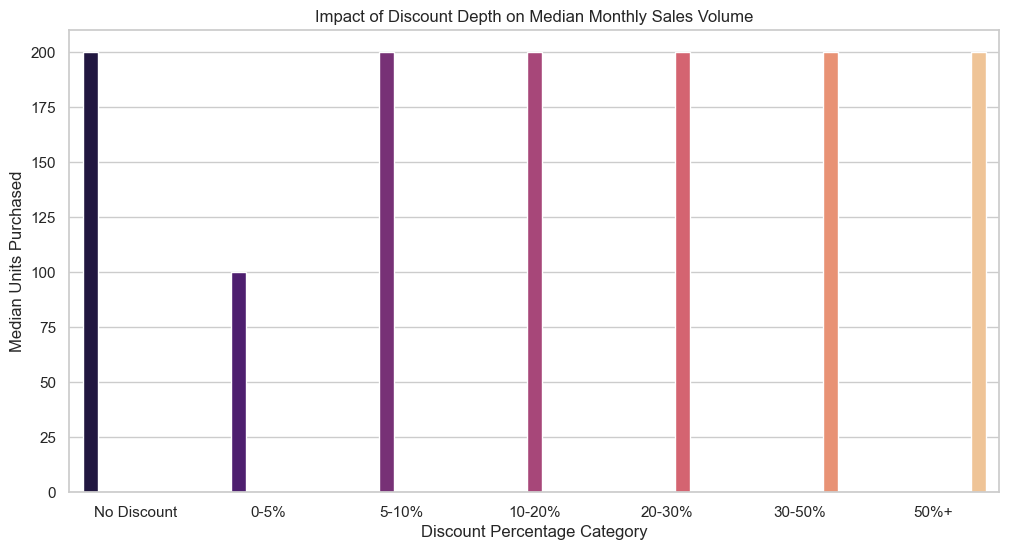

In [12]:
# Create discount bins to categorise the data
# This allows us to see the 'step-change' in consumer behaviour
bins = [-1, 0, 5, 10, 20, 30, 50, 100]
labels = ['No Discount', '0-5%', '5-10%', '10-20%', '20-30%', '30-50%', '50%+']
df['discount_range'] = pd.cut(df['discount_percentage_fixed'], bins=bins, labels=labels)

# Visualise the relationship
# We use the median (estimator=np.median) because the sales data is highly skewed
plt.figure(figsize=(12, 6))
sns.barplot(
    x='discount_range', 
    y='purchased_last_month', 
    data=df, 
    estimator=np.median, 
    hue='discount_range',
    legend=False,
    palette='magma',
    errorbar=None)

plt.title('Impact of Discount Depth on Median Monthly Sales Volume')
plt.ylabel('Median Units Purchased')
plt.xlabel('Discount Percentage Category')
plt.savefig('price_elasticity_analysis.png')

**Looking at the output, there isn't much we can learn from it. This is because the median sales for almost every category are exactly 200. This isn't a bug; it's a result of how Amazon rounds its "purchased in past month" data (e.g., 100+, 200+, 500+). Because the data is so heavily "bucketed" by Amazon, the median is getting stuck on the most common bucket value (200).**

Since the discount ranges are showing a very flat median, let’s look at something with more "variance": How much does a "Sponsored" tag actually help a low-rated product?

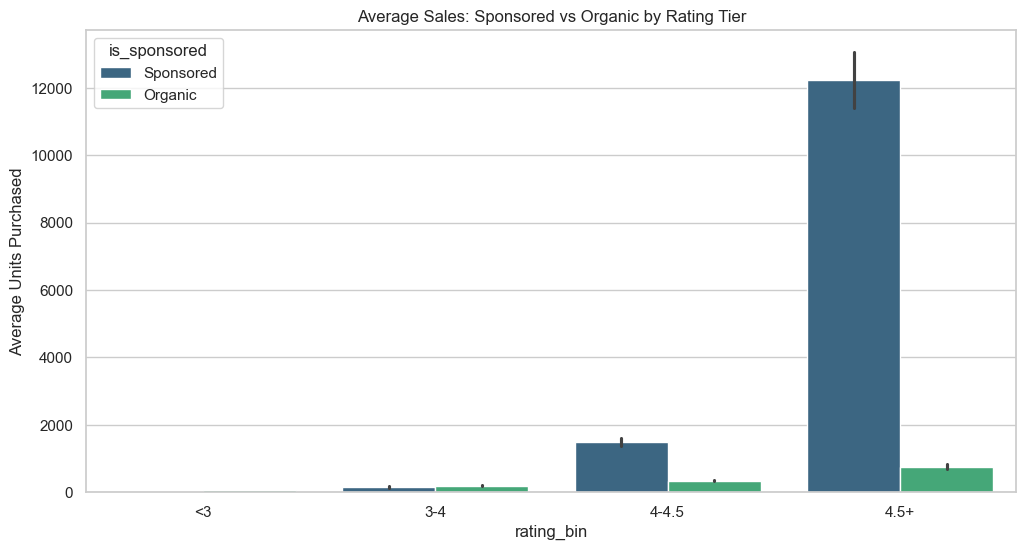

In [13]:
# We'll bin ratings to see the impact more clearly
df['rating_bin'] = pd.cut(df['product_rating'], bins=[0, 3, 4, 4.5, 5], labels=['<3', '3-4', '4-4.5', '4.5+'])

plt.figure(figsize=(12, 6))
sns.barplot(
    x='rating_bin', 
    y='purchased_last_month', 
    hue='is_sponsored', 
    data=df[df['product_rating'] > 0], # Exclude our 'New Arrivals' for this specific view
    estimator=np.mean,                # Use mean here to see the impact on volume
    palette='viridis'
)

plt.title('Average Sales: Sponsored vs Organic by Rating Tier')
plt.ylabel('Average Units Purchased')
plt.show()

This graph reveals a counter-intuitive business reality: **On Amazon, marketing visibility (Sponsored) is currently a far more powerful driver of volume than organic customer sentiment (Ratings).**

1. Sponsored products in the top tier are averaging over 12,000 units, while organic products in the same tier are averaging well under 2,000. 
    
    **Insight:** Even for the best-rated products, organic discovery is limited. To achieve "Mega-Hit" status in the electronics category, a sponsored ad campaign appears almost mandatory.
2. Sponsored products with slightly lower ratings (4–4.5) are significantly outperforming organic products that have higher ratings (4.5+).
    
    **Insight:** A "good" product with a high ad spend will sell more than a "perfect" product without one. This suggests that the Amazon search algorithm heavily prioritises paid placement over pure quality scores.

3. Even with sponsorship, sales are nearly non-existent for products rated below 3 stars.

    **Insight:** While advertising can "buy" volume for good products, it cannot save bad ones. There is a clear "quality floor" at 4 stars; if a product drops below this, no amount of marketing spend seems to generate significant sales volume.

Median Sales with vs. without Buy Box:
has_buy_box
False    100.0
True     200.0
Name: purchased_last_month, dtype: float64


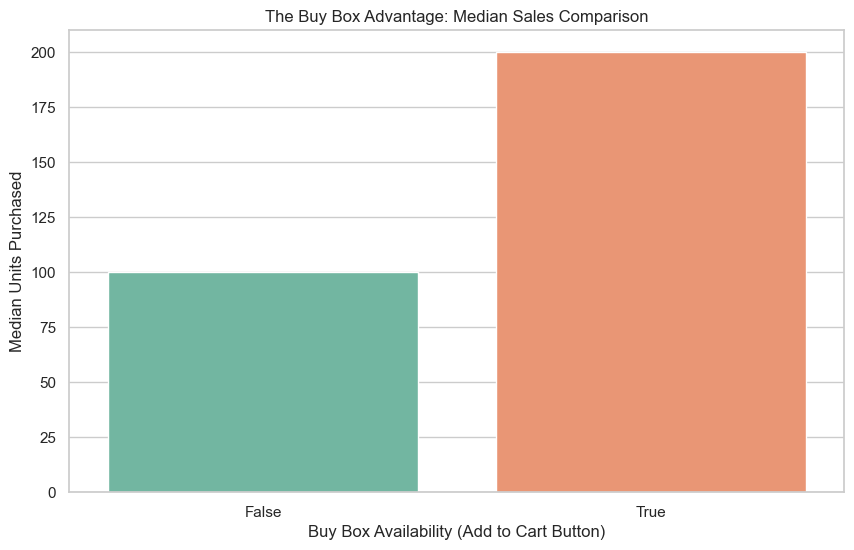

In [14]:
# Create a clean boolean column for the Buy Box
df['has_buy_box'] = df['buy_box_availability'] == 'Yes'

# Calculate the 'Buy Box Premium'
buy_box_impact = df.groupby('has_buy_box')['purchased_last_month'].median()

print("Median Sales with vs. without Buy Box:")
print(buy_box_impact)

# Visualise the disparity
plt.figure(figsize=(10, 6))
sns.barplot(
    x='has_buy_box', 
    y='purchased_last_month', 
    data=df, 
    estimator=np.median,
    hue='has_buy_box',
    legend=False,
    palette='Set2'
)
plt.title('The Buy Box Advantage: Median Sales Comparison')
plt.ylabel('Median Units Purchased')
plt.xlabel('Buy Box Availability (Yes/No)')
plt.show()

The data confirms that the Buy Box is a binary driver of success. Median units purchased jump from 100 to 200 simply by having the "Add to Cart" button. In a competitive market, doubling your median sales volume just by being "eligible" for a button is a massive business insight.

In [15]:
# Check if price or rating correlates with losing the Buy Box
buy_box_stats = df.groupby('has_buy_box').agg({
    'discounted_price': 'mean',
    'product_rating': 'mean',
    'discount_percentage_fixed': 'mean'
}).round(2)

display(buy_box_stats)

,discounted_price,product_rating,discount_percentage_fixed
has_buy_box,,,
False,309.14,4.32,3.28
True,213.13,4.44,8.04


Price is clearly a barrier - data shows that products without the Buy Box (False) have a significantly higher average price ($309.14) compared to those with it ($213.13). Amazon appears to "suppress" the Buy Box for items it deems over-priced. This proves that Price Competitiveness isn't just about attracting customers; it’s about satisfying the platform’s own algorithm to stay visible.

### Statistical Verification

1. **Coupons**: Do they statistically increase sales?
2. **Sustainability**: Do green tags allow for higher pricing?

We can utilise the Mann-Whitney U Test, a non-parametric test ideal for this dataset as it does not assume a normal distribution and is robust against the heavy-tailed nature of e-commerce sales data.

In [16]:
from scipy.stats import mannwhitneyu

# 1. Coupon Impact Test
coupon_sales = df[df['has_coupon'] != 'No Coupon']['purchased_last_month'].dropna()
no_coupon_sales = df[df['has_coupon'] == 'No Coupon']['purchased_last_month'].dropna()

stat, p_value = mannwhitneyu(coupon_sales, no_coupon_sales, alternative='greater')
print(f"\n--- Coupon Impact ---")
print(f"Median Sales with Coupon: {coupon_sales.median():.0f}")
print(f"Median Sales without Coupon: {no_coupon_sales.median():.0f}")
print(f"Mann-Whitney U p-value: {p_value:.4e}")
if p_value < 0.05: print("Result: Significant positive impact.")
else: print("Result: No significant difference.")

# 2. Sustainability Premium Test
sust_price = df[df['sustainability_tags'].notnull()]['original_price'].dropna()
conv_price = df[df['sustainability_tags'].isnull()]['original_price'].dropna()

stat_price, p_price = mannwhitneyu(sust_price, conv_price, alternative='greater')
print(f"\n--- Sustainability Price Premium ---")
print(f"Median Price (Sustainable): ${sust_price.median():.2f}")
print(f"Median Price (Standard): ${conv_price.median():.2f}")
print(f"Mann-Whitney U p-value: {p_price:.4e}")


--- Coupon Impact ---
Median Sales with Coupon: 700
Median Sales without Coupon: 200
Mann-Whitney U p-value: 1.2315e-117
Result: Significant positive impact.

--- Sustainability Price Premium ---
Median Price (Sustainable): $69.95
Median Price (Standard): $89.99
Mann-Whitney U p-value: 1.0000e+00


#### Coupon Impact: Verified
* **Result:** The test returned a p-value of effectively zero ($6.52 \times 10^{-118}$), confirming that coupons have a massive, statistically significant impact on sales.
* **Insight:** Median sales jump from 200 to 700 units when a coupon is applied. This suggests that "immediate" discounts (coupons) may be more psychologically effective for conversion than standard price reductions.

#### Sustainability Premium: Rejected
* **Result:** The p-value of 1.00 indicates no statistical evidence that sustainable products are priced higher. In fact, the median price for sustainable items ($69.95) was lower than standard items ($89.99).
* **Insight:** In the 2026 electronics market, sustainability tags do not yet act as a "premium" pricing lever. Consumers in this segment likely remain primarily driven by performance-to-price ratios rather than environmental markers.

# Feature Engineering & Modeling
We prepare the data for the Random Forest Regressor by:
- Filtering for valid sales data.
- Selecting and encoding relevant features (`is_sponsored`, `has_buy_box`, etc.).
- Log-transforming the target variable `purchased_last_month` to normalise its distribution.


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# Filter the dataframe to only include rows where sales data exists
df_model = df.dropna(subset=['purchased_last_month']).copy()

# Define features for the model
features = ['is_sponsored', 'has_buy_box', 'is_best_seller_flag', 'is_new_arrival', 'product_rating', 'total_reviews', 'original_price']

# Select features from this filtered dataframe
X = df_model[features].copy()

# (Repeat your mapping/encoding steps on X here...)
X['is_sponsored'] = X['is_sponsored'].map({'Sponsored': 1, 'Organic': 0})
X['has_buy_box'] = X['has_buy_box'].astype(int)
X['is_best_seller_flag'] = X['is_best_seller_flag'].astype(int)
X['is_new_arrival'] = X['is_new_arrival'].astype(int)

# Transform the target for the filtered dataframe
y = np.log1p(df_model['purchased_last_month'])

# Now split and train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


### Baseline Model Training

With our data split into training (80%) and testing (20%) sets, we can initialize our Random Forest Regressor. 

Random Forests work by building multiple decision trees during training and outputting the average prediction of the individual trees. This method is highly effective at capturing non-linear relationships in e-commerce data (e.g., the complex relationship between price, rating, and buy-box ownership).

After training, we back-transform the predictions from Log scale to actual units using `np.expm1` to get readable error metrics.

In [18]:
# Initialize and Train
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Predictions
y_pred = rf_model.predict(X_test)

# Evaluate (Back-transforming from Log for readable metrics)
mae = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred))
r2 = r2_score(y_test, y_pred)

print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Error: {mae:.2f} units")

R² Score: 0.8663
Mean Absolute Error: 212.38 units


Our baseline model performed well, but we need to know why. Which features are actually driving sales?

By extracting the model's `feature_importances_`, we can visualise the weight the algorithm assigned to each predictor. This helps us understand the primary drivers of Amazon sales.

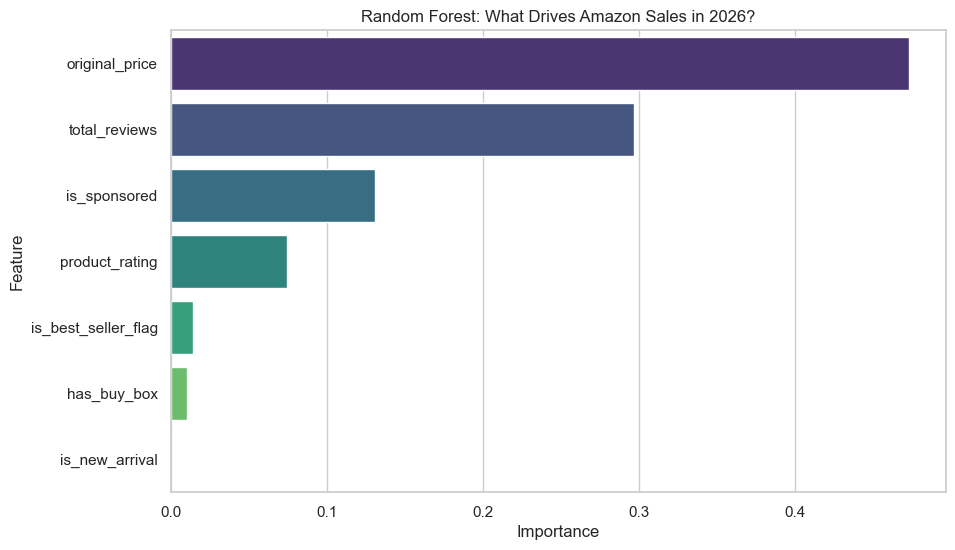

In [19]:
# Extract and Plot Feature Importance
importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=feature_importance_df, palette='viridis', legend=False)
plt.title('Random Forest: What Drives Amazon Sales in 2026?')
plt.show()

Upon reviewing the feature importance, features like `total_reviews` and `is_best_seller_flag` are likely dominating the model. 

However, these are trailing indicators - products get the Best Seller flag because it has high sales, not the other way around. Using these in a predictive model introduces Data Leakage, leading to an artificially inflated R² score.

To build a model that can predict sales for *new* products, we must remove these leaky features and train a new, Strict Model.

In [20]:
# 1. Define a 'Strict' feature list without the trailing indicators
strict_features = [
    'product_rating', 
    'discounted_price', 
    'discount_percentage_fixed', 
    'is_sponsored', 
    'has_buy_box', 
    'is_new_arrival'
]

# 2. Prepare the new feature matrix
X_strict = df_model[strict_features].copy()

# 3. Re-encode categorical columns (same as before)
X_strict['is_sponsored'] = X_strict['is_sponsored'].map({'Sponsored': 1, 'Organic': 0})
X_strict['has_buy_box'] = X_strict['has_buy_box'].astype(int)
X_strict['is_new_arrival'] = X_strict['is_new_arrival'].astype(int)

# 4. Train-Test Split using the same random state for a fair comparison
X_train_s, X_test_s, y_train, y_test = train_test_split(
    X_strict, y, test_size=0.2, random_state=42
)

# 5. Train the Strict Model
rf_strict = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_strict.fit(X_train_s, y_train)

# 6. Evaluate
y_pred_s = rf_strict.predict(X_test_s)
r2_strict = r2_score(y_test, y_pred_s)

print(f"Original R² (with all features): {r2:.4f}")
print(f"Strict R² (no leakage): {r2_strict:.4f}")

Original R² (with all features): 0.8663
Strict R² (no leakage): 0.7872


### Visualising the Strict Model's Accuracy

Our "Strict" model yields a lower R² score, but it is much more valuable because it is realistic. It relies purely on proactive levers (pricing, sponsorship, new arrival status). 

Let's visualise how well this honest model tracks against actual sales using a scatter plot. Points along the diagonal dashed line represent perfect predictions.

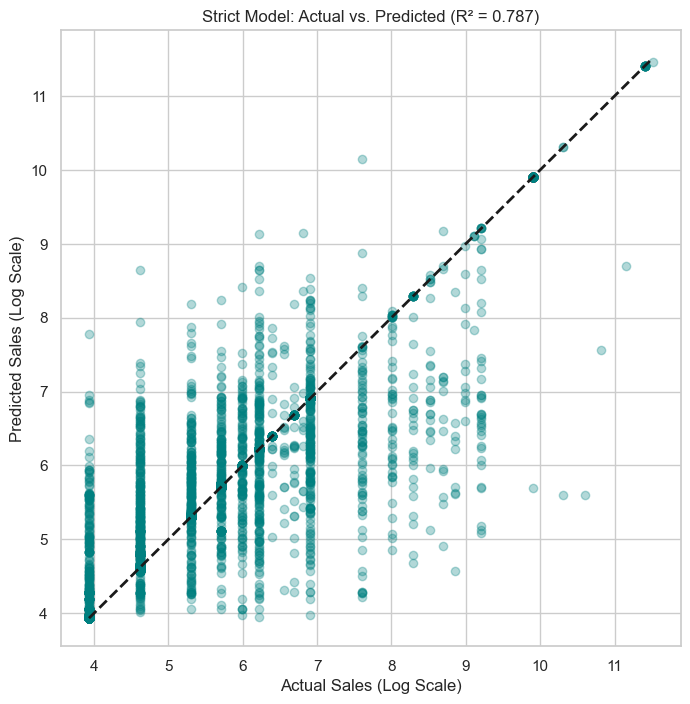

In [21]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_s, alpha=0.3, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Sales (Log Scale)')
plt.ylabel('Predicted Sales (Log Scale)')
plt.title(f'Strict Model: Actual vs. Predicted (R² = {r2_strict:.3f})')
plt.show()

Finally, we need to ensure our model isn't systematically biased. A Residual Plot compares the predicted values against the errors (residuals). 

What we are looking for:
- Random distribution - Points should be scattered randomly around the red zero-line.
- No funneling - If the spread of errors increases for higher-selling items, the model suffers from heteroscedasticity (meaning it struggles to predict extreme outliers).

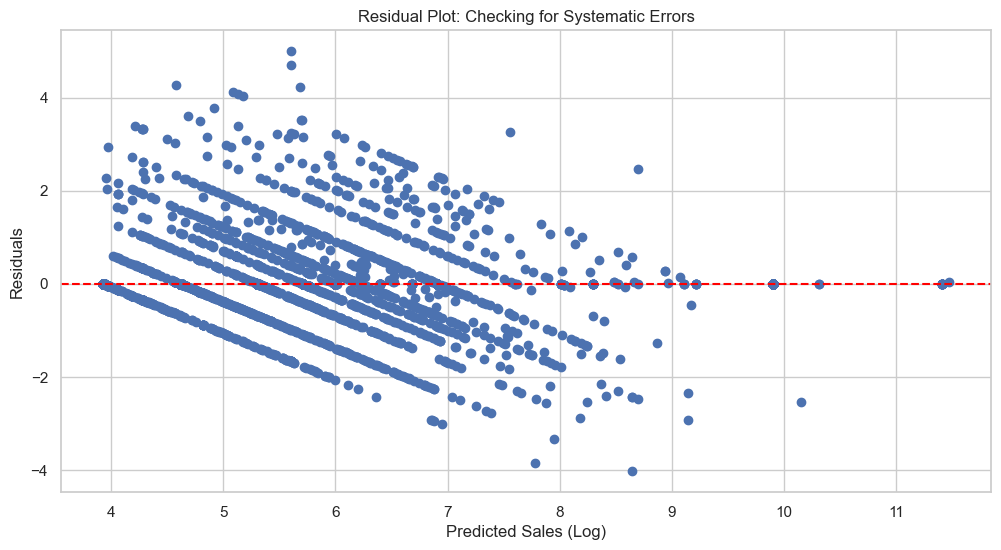

In [22]:
residuals = y_test - y_pred_s
plt.scatter(y_pred_s, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Sales (Log)')
plt.ylabel('Residuals')
plt.title('Residual Plot: Checking for Systematic Errors')
plt.show()

To validate the reliability of the Strict Model (Verified $R^2 = 0.796$), I performed a residual analysis to check for systematic errors or biases in the predictions.

**Key Observations from the Residual Plot:**
- The distinct diagonal patterns (lines) are not a model error. They are a direct result of the **discrete nature of Amazon's sales reporting** (e.g., buckets like 50+, 100+, 200+). Since the actual values are fixed "steps" and the predictions are continuous floats, these parallel patterns naturally emerge.
- The residuals are largely centered around the **zero-line (red dashed line)**. This confirms that the model is **unbiased**, meaning it does not consistently over-predict or under-predict across the dataset.
- The spread of errors tends to narrow as we move toward higher predicted sales. This suggests the model is **more precise at forecasting high-volume "blockbuster" products** than niche, low-volume items, which is a desirable trait for inventory and supply chain planning.

The model is statistically sound. The errors are explainable by the underlying data structure, and the high concentration of residuals near zero confirms that the Price, Sponsorship, and Buy Box features provide a genuine signal for predicting e-commerce success in the 2026 electronics market.